### Tenacity - Retrying LLM calls

In [ ]:
import random

def flaky_llm_call(prompt: str):
    if random.random() < 0.5: 
        raise Exception("429: Too many api calls")
    return f"LLM response to: {prompt}"

In [ ]:
# Without tenacity
def call_llm(prompt: str):
    return flaky_llm_call(prompt)

random.seed(1) # on 2 llm call is happening. not on 1 and 4

try:
    print(call_llm("What is gpt"))
except Exception as e:
    print(f"call failed: {str(e)}")

In [ ]:
# With tenacity
from tenacity import retry, stop_after_attempt, wait_fixed

@retry(
    stop= stop_after_attempt(3), # 3 retry calls only
    wait= wait_fixed(2),         # wait for 2 sec after every retry
    reraise= True                # overwrites tenacity's retry error with actual function error 
)
def call_llm_basic_retry(prompt: str):
    print("Attempting call") # one time it is always printed, second time print means error occured
    return flaky_llm_call(prompt)

random.seed(2)

call_llm_basic_retry("Provide me bun")

In [ ]:
# Exceptional backoff with tenacity: wait time increases exponentially
from tenacity import wait_exponential, RetryCallState

def log_retry(retry_state: RetryCallState) -> None:
    wait_time = retry_state.next_action.sleep # tenacity tells us how long it's about to sleep
    print(f"Attempt: {retry_state.attempt_number} failed -- retrying in {wait_time:.1f}s..")

attempts_so_far = {'count':0} # forces first 3 calls to fail, so we can watch backoff escalates

def flaky_llm_call_backoff(prompt str) -> None:
    attempts_so_far['count'] += 1
    if attempts_so_far['count'] < 4:
        raise Exception("429: Too many requests")
    return f"LLM response for: {prompt}"

@retry(
    stop= stop_after_attempt(5), # stop after 5 attempts
    # min wait=2sec, max wait=10sec, multiper means first wait 2sec, 2sec, 4sec, 4sec,....10sec
    wait= wait_exponential(multipier=1, min=2, max=10), 
    before_sleep= log_retry, #printing wait time as defined above
    reraise= True
)
def call_llm_backoff(prompt: str):
    return flaky_llm_call_backoff(prompt)

call_llm_backoff("Explain backoff retry")

In [ ]:
# Retry on specific exceptions
from tenacity import retry_if_exception_type

def log_retry_exception(retry_state: RetryCallState) -> None:
    wait_time = retry_state.next_action.sleep
    print(f"Attempt: {retry_state.attempt_number} failed -- retrying in {wait_time:.1f}s")

class InvalidRequestError(Exception):
    pass

@retry(
    stop= stop_after_attempt(5),
    wait= wait_fixed(1),
    retry= retry_if_exception_type((TimeoutError, InvalidRequestError)), # only retry these two
    before_sleep= log_retry_exception,
    reraise= True
)
def call_llm_custom_exception(prompt: str, error_type:type[Exception]= TimeoutError):
    if error_type:
        raise error_type("Simulated failure")
    return f"LLM response: {prompt}"

# A trainsent error retries 3 times then raises error
try:
    call_llm_custom_exception("test",error_type=TimeoutError)
except TimeoutError:
    print('Give up after retries on a TimeOutError')

try:
    call_llm_custom_exception("test",error_type=InvalidRequestError)
except InvalidRequestError:
    print('Failed immediately on InvalidRequestError -- no retries attempted')

In [ ]:
# Real LLM call with tenacity

@retry(
    stop= 5,
    wait_fixed= wait_exponential(multipler=1, min=2, max=10),
    retry= retry_if_exception_type((openai.RateLimitError, openai.APITimeOutError, openai.APIConnectionError)), # only retry these two
    before_sleep= log_retry_exception,
    reraise= True
)
def call_real_llm(prompt: str, client=openai.OpenAI):
    response = client.chat.completions.create(
        model= 'gpt-4o-mini',
        message= [{'role':'user','content':prompt}]
    )
    return response.choices[0].message.content

client= openai.OpenAI(api_key="sdfagsg")
print(call_real_llm('Say hello',client=client))

In [ ]:
2+2

#### Testing web search tool (TavilySearch)

In [ ]:
from components.tools.websearch_tool import internet_search

In [ ]:
search = internet_search(query="what is the capital of France")

In [ ]:
print(search)

In [ ]:
print(search['query'])

In [ ]:
print(search['results'][0]['content'])

In [ ]:
response = []
for i, r in enumerate(search["results"], 1):
    title   = r.get("title", "Unknown")
    url     = r.get("url", "")
    snippet = r.get("content", "").strip()
    # Keep only the first 300 characters to avoid wall-of-text
    if len(snippet) > 300:
        snippet = snippet[:300].rsplit(" ", 1)[0] + "..."

    response.append(f"{i}. **{title}**\n   {url}\n   {snippet}")

In [ ]:
print(response)

In [ ]:
result = internet_search("Find flights between Mumbai to Kolkata on 25 August 2026")

In [ ]:
result

### Testing flight tool (avaitation stack)

In [ ]:
from components.tools.flight_tool import search_flight

In [ ]:
flight_result = search_flight("flights between BOM to MAA")

In [ ]:
print(flight_result)

In [ ]:
print(flight_result[0])

In [ ]:
another_search = search_flight({
    "dep_iata": "DAC",   # Tokyo
    "arr_iata": "NRT",    # Mumbai
    "flight_date": "2026-08-25"
}, limit=10)

for f in another_search:
    print(f"Airline: {f['airline']['name']}, Flight: {f['flight']['iata']}, "
          f"From: {f['departure']['airport']} → To: {f['arrival']['airport']}, "
          f"Status: {f['flight_status']}")


In [ ]:
print(another_search)

In [ ]:
dep_iata= "DAC",   # Tokyo
arr_iata= "NRT",
route_info = "Global live flights"

if dep_iata and arr_iata:
    route_info = f"Live flights from {dep_iata} to {arr_iata}"
elif dep_iata:
    route_info = f"Live flights from {dep_iata}"
elif arr_iata:
    route_info = f"Live flights to {arr_iata}"

print(route_info)

In [ ]:
import requests

params = {
  'access_key': key
}

api_result = requests.get('https://api.aviationstack.com/v1/flights', params)

api_response = api_result.json()

for flight in api_response['data']:
    if (flight['live']['is_ground'] is False):
        print(u'%s flight %s from %s (%s) to %s (%s) is in the air.' % (
            flight['airline']['name'],
            flight['flight']['iata'],
            flight['departure']['airport'],
            flight['departure']['iata'],
            flight['arrival']['airport'],
            flight['arrival']['iata']))

In [ ]:
api_response['data'][0]

In [ ]:
from components.utils import clean_text,airport_country_matches,get_best_airport_for_country,country_name_to_code

In [ ]:
text = clean_text("Where flights runs from Mumbai for sightseeing")
print(text)

In [ ]:
code = country_name_to_code("Which flight goes to South Korea")
print(code)

In [ ]:
from components.utils import AIRPORTS

In [ ]:
airport_country_matches(airport=AIRPORTS, country_code=code)
#print(f"airport: {airport}, country: {country}")

In [ ]:
from components.tools.flight_tool import search_flights

In [ ]:
res = search_flights("Plan a 7 days Japan trip from Mumbai")
print(res)

In [ ]:
from datetime import datetime, date

custom_date= date(2026,8,26)
print(custom_date)

format_date = now.strftime("%Y-%m-%d")
print("formatted_date", format_date)

In [ ]:
from datetime import datetime
from dateutil import parser

def extract_date_from_query(query: str) -> str:
    """
    Extracts a date from user query and returns it in ISO 8601 format (YYYY-MM-DD).
    """
    try:
        # Use dateutil parser to handle flexible date formats
        dt = parser.parse(query, fuzzy=True)
        return dt.date().isoformat()  # Only date part, e.g. "2026-08-31"
    except Exception as e:
        return f"Error extracting date: {e}"

# Example usage
query = "Create a plan on 31 August 2026."
iso_date = extract_date_from_query(query)
print("Extracted ISO date:", iso_date)


In [ ]:
from datetime import timedelta
query_1 = "Plan a trip to mumbai on 30 august 2026"
query_2 = "Plan a trip to mumbai"

def format_date(query):
    try:
        dt = parser.parse(query, fuzzy=True)
        formatted_date = dt.date().isoformat()
    except:
        default_date = date.today() + timedelta(days=2)
        formatted_date = default_date.isoformat()
    return formatted_date

query_1_date = format_date(query_1)
query_2_date = format_date(query_2)


In [ ]:
print(f"first query: {query_1_date}")
print(f"second query: {query_2_date}")

In [ ]:
from components.graph.state import initial_state

In [ ]:
re = initial_state("new trip")
re

In [ ]:
print(re)

In [ ]:
from components.prompts.final_response_prompt import FINAL_RESPONSE_PROMPT

In [ ]:
FINAL_RESPONSE_PROMPT

In [ ]:
from components.prompts.itineary_prompt import ITINERARY_AGENT_PROMPT

In [ ]:
print(ITINERARY_AGENT_PROMPT)

In [ ]:
from components.graph.workflow import trip_graph

In [ ]:
configs = {'configurable': {'thread_id':'prav'}}

In [ ]:
trip_graph.update_state(
    configs,
    {
        'flight_result':"Scheduled to BOM",
        'hotel_result': "Few available",
        "itineary_result": "not booked"
    }
)

In [ ]:
print("-"*80)
print(f"Initial state:")
print("-"*80)
print("messages: ", re['messages'])
print("user_query: ", re['user_query'])
print("flight_result: ", re['flight_result'])
print("weather_result: ", re['weather_result'])
print("hotel_result: ", re['hotel_result'])
print("itineary_result: ", re['itineary_result'])
print("approved: ", re['approved'])
print("travellers: ", re['travellers'])
print("date: ", re['date'])
print("="*80)
# Fetch the current state snapshot
current_state = trip_graph.get_state(configs)

print("=== Current State Values ===")
# .values contains the actual data (your state keys and their current data)
for key, value in current_state.values.items():
    print(f"{key}: {value}")

# Optional: Print metadata like next steps or pending tasks
print("\n=== State Metadata ===")
print(f"Next Node(s) to execute: {current_state.next}")
print(f"Task ID / Checkpoint ID: {current_state.config['configurable'].get('checkpoint_id')}")

In [1]:
from components.prompts.itineary_prompt import itineary_agent_prompt
from components.prompts.final_response_prompt import response_prompt
from components.graph.state import AgentState

In [5]:
def itineary_agent(state):
    itineary_prompt = itineary_agent_prompt.format(
        user_query = state.get("user_query", ""),
        flight_result = state.get("flight_result", ""),
        weather_result = state.get("weather_result", ""),
        hotel_result = state.get("hotel_result", "")
    )
    return itineary_prompt
itineary_agent_prompt = itineary_agent(AgentState)
print(f"itineary agent prompt: {itineary_agent_prompt}")
print("-"*80)
def final_response(state):
    prompt = response_prompt.format(
        user_uery = state.get("user_query", ""),
        flight_result = state.get("flight_result", ""),
        hotel_result = state.get("hotel_result", ""),
        itinerary = state.get("itineary_result", ""),
        weather_result = state.get("weather_result", "")
    )
    return prompt
response = final_response(AgentState)
print(f"response agent prompt: {response}")

TypeError: descriptor 'get' for 'dict' objects doesn't apply to a 'str' object

In [8]:
from components.prompts.itineary_prompt import itineary_agent_prompt
print(itineary_agent_prompt.template)


    Create a complete travel itinerary.

    User Query:
    {user_query}

    Flight Results:
    {flight_result}

    Hotel Results:
    {hotel_result}

    Weather Results:
    {weather_result}

    Make the itinerary practical, budget-aware, and easy to follow.
    


In [ ]:
from components.graph.state import initial_state

In [3]:
print("initial_state: ", initial_state("how are you"))

initial_state:  {'messages': [], 'user_query': 'how are you', 'flight_result': '', 'weather_result': '', 'hotel_result': '', 'itineary_result': '', 'approved': False, 'travellers': 2, 'date': <class 'str'>}


In [ ]:
state = initial_state("I want to travel to Goa on 30 August")

print(state)
print("DATE:", state["date"])
print("DATE TYPE:", type(state["date"]))

{'messages': [], 'user_query': 'I want to travel to Goa on 30 August', 'flight_result': '', 'weather_result': '', 'hotel_result': '', 'itineary_result': '', 'approved': False, 'travellers': 2, 'date': <class 'str'>}
DATE: <class 'str'>
DATE TYPE: <class 'type'>


### Parallel Workflow

In [4]:
from langgraph.graph import START, END, StateGraph
from typing import Literal, TypedDict

In [3]:
class ParallelState(TypedDict):

    topic: str
    research: str
    review: str
    draft: str
    revoke: str
    final: str

In [17]:
# define all nodes
def user_topic(state: ParallelState) -> ParallelState:
    user_input = state.get('topic', "")
    state['topic'] = user_input
    return state

def topic_research(state: ParallelState) -> ParallelState:
    content = "This workflow helps in doing work simulataneously, as non of the node work is depending on other nodes"
    state["research"] = content
    return state

def topic_review(state: ParallelState) -> dict:
    content_review = "The content of the draft is accurate and ready to go to next stage"
    return {
        'review': content_review
    }

def topic_draft(state: ParallelState) -> dict:
    content_draft = "The draft will take time to get prepared"
    return {
        'draft': content_draft
    }

def topic_revoke(state: ParallelState) -> dict:
    content_revoke = "The content need not be revoked as it is under the guidelines"
    return {
        'revoke': content_revoke
    }

def final_node(state: ParallelState) -> ParallelState:
    content_final = "The final draft is getting processed"
    state['final'] = content_final
    return state

In [18]:
graph = StateGraph(ParallelState)

graph.add_node("topic", user_topic)
graph.add_node("research", topic_research)
graph.add_node("review", topic_review)
graph.add_node("draft", topic_draft)
graph.add_node("revoke", topic_revoke)
graph.add_node("final", final_node)

graph.add_edge(START, "topic")
graph.add_edge("topic", "research")

graph.add_edge("research", "review")
graph.add_edge("research", "draft")
graph.add_edge("research", "revoke")

graph.add_edge("review", "final")
graph.add_edge("draft", "final")
graph.add_edge("revoke", "final")

graph.add_edge("final", END)

parallel_workflow = graph.compile()

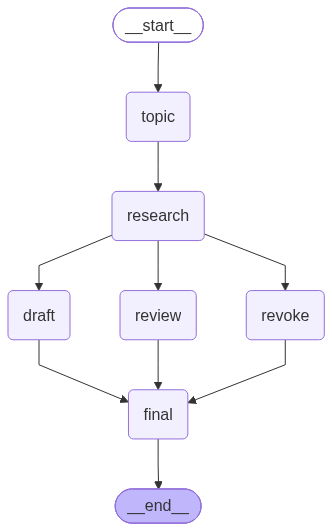

In [9]:
parallel_workflow

In [19]:
def parallel_initial_state(topic: str = "Parallel Workflow in Langgraph"):
    return {
    "topic": topic,
    "research": "",
    "review": "",
    "draft": "",
    "revoke": "",
    "final": ""
}

In [20]:
response = parallel_workflow.invoke(parallel_initial_state())
print(response)

{'topic': 'Parallel Workflow in Langgraph', 'research': 'This workflow helps in doing work simulataneously, as non of the node work is depending on other nodes', 'review': 'The content of the draft is accurate and ready to go to next stage', 'draft': 'The draft will take time to get prepared', 'revoke': 'The content need not be revoked as it is under the guidelines', 'final': 'The final draft is getting processed'}


In [ ]:
response

{'topic': 'Parallel Workflow in Langgraph',
 'research': 'This workflow helps in doing work simulataneously, as non of the node work is depending on other nodes',
 'review': 'The content of the draft is accurate and ready to go to next stage',
 'draft': 'The draft will take time to get prepared',
 'revoke': 'The content need not be revoked as it is under the guidelines',
 'final': 'The final draft is getting processed'}

### Conditional Workflow

In [22]:
class ConditionalState(TypedDict):

    topic: str
    research: str
    review: str
    draft: str
    revoke: str
    final: str

In [39]:
# define all nodes
def user_topic(state: ConditionalState) -> ConditionalState:
    user_input = state.get('topic', "")
    state['topic'] = user_input
    return state

def topic_research(state: ConditionalState) -> ConditionalState:
    content = "This workflow helps in doing work simulataneously, as non of the node work is depending on other nodes"
    state["research"] = content
    return state

def topic_review(state: ConditionalState) -> dict:
    content_review = "The content of the draft is accurate and ready to go to next stage"
    return {
        'review': content_review
    }

def topic_draft(state: ConditionalState) -> dict:
    content_draft = "The draft will take time to get prepared"
    return {
        'draft': content_draft
    }

def topic_revoke(state: ConditionalState) -> dict:
    content_revoke = "The content need not be revoked as it is under the guidelines"
    return {
        'revoke': content_revoke
    }

def final_node(state: ConditionalState) -> ConditionalState:
    content_final = "The final draft is getting processed"
    state['final'] = content_final
    return state

In [29]:
import random
result = random.randint(1,3)
print(result)

1


In [53]:
def route_condition(state: ConditionalState) -> Literal["review", "draft", "revoke"]:
    result = random.randint(0,2)
    routes = ["review", "draft", "revoke"]
    return routes[result]

In [54]:
graph = StateGraph(ConditionalState)

graph.add_node("topic", user_topic)
graph.add_node("research", topic_research)
graph.add_node("review", topic_review)
graph.add_node("draft", topic_draft)
graph.add_node("revoke", topic_revoke)
graph.add_node("final", final_node)

graph.add_edge(START, "topic")
graph.add_edge("topic", "research")

graph.add_conditional_edges("research", route_condition)

graph.add_edge("review", "final")
graph.add_edge("draft", "final")
graph.add_edge("revoke", "final")

graph.add_edge("final", END)

conditional_workflow = graph.compile()

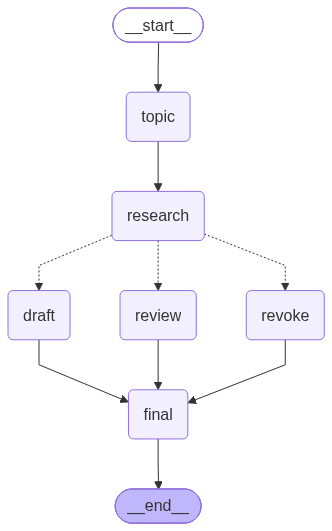

In [34]:
conditional_workflow

In [40]:
def conditional_initial_state(topic: str = "Parallel Workflow in Langgraph"):
    return {
    "topic": topic,
    "research": "",
    "review": "",
    "draft": "",
    "revoke": "",
    "final": ""
}

In [44]:
res = conditional_workflow.invoke(conditional_initial_state())
res

{'topic': 'Parallel Workflow in Langgraph',
 'research': 'This workflow helps in doing work simulataneously, as non of the node work is depending on other nodes',
 'review': '',
 'draft': '',
 'revoke': 'The content need not be revoked as it is under the guidelines',
 'final': 'The final draft is getting processed'}

In [45]:
print("2 iteration")
res = conditional_workflow.invoke(conditional_initial_state())
res

2 iteration


{'topic': 'Parallel Workflow in Langgraph',
 'research': 'This workflow helps in doing work simulataneously, as non of the node work is depending on other nodes',
 'review': 'The content of the draft is accurate and ready to go to next stage',
 'draft': '',
 'revoke': '',
 'final': 'The final draft is getting processed'}

In [46]:
print("3 iteration")
res = conditional_workflow.invoke(conditional_initial_state())
res

3 iteration


{'topic': 'Parallel Workflow in Langgraph',
 'research': 'This workflow helps in doing work simulataneously, as non of the node work is depending on other nodes',
 'review': '',
 'draft': '',
 'revoke': 'The content need not be revoked as it is under the guidelines',
 'final': 'The final draft is getting processed'}

In [47]:
print("4 iteration")
res = conditional_workflow.invoke(conditional_initial_state())
res

4 iteration


{'topic': 'Parallel Workflow in Langgraph',
 'research': 'This workflow helps in doing work simulataneously, as non of the node work is depending on other nodes',
 'review': '',
 'draft': '',
 'revoke': 'The content need not be revoked as it is under the guidelines',
 'final': 'The final draft is getting processed'}

In [48]:
print("5 iteration")
res = conditional_workflow.invoke(conditional_initial_state())
res

5 iteration


{'topic': 'Parallel Workflow in Langgraph',
 'research': 'This workflow helps in doing work simulataneously, as non of the node work is depending on other nodes',
 'review': 'The content of the draft is accurate and ready to go to next stage',
 'draft': '',
 'revoke': '',
 'final': 'The final draft is getting processed'}

In [49]:
print("6 iteration")
res = conditional_workflow.invoke(conditional_initial_state())
res

6 iteration


{'topic': 'Parallel Workflow in Langgraph',
 'research': 'This workflow helps in doing work simulataneously, as non of the node work is depending on other nodes',
 'review': 'The content of the draft is accurate and ready to go to next stage',
 'draft': '',
 'revoke': '',
 'final': 'The final draft is getting processed'}

In [52]:
print("7 iteration")
res = conditional_workflow.invoke(conditional_initial_state())
res

7 iteration


{'topic': 'Parallel Workflow in Langgraph',
 'research': 'This workflow helps in doing work simulataneously, as non of the node work is depending on other nodes',
 'review': '',
 'draft': 'The draft will take time to get prepared',
 'revoke': '',
 'final': 'The final draft is getting processed'}

### Human in the Loop

In [13]:
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage, AIMessage
from typing import Annotated

In [19]:
class HITLState(TypedDict):

    message: Annotated[list[BaseMessage], add_messages]
    llm_response: str

In [48]:
# nodes
def messages(state: HITLState):

    decision = interrupt({
        "type": "approval",
        "reason": "An LLM call is to make",
        "question": state["message"][-1].content,
        "instruction": "Approve this question? yes/no"
    })

    if decision["approved"] == "no":
        return {'message': [AIMessage(content="Not Approved")]}
    else:
        result = state.get('llm_response', "I need an intrenet search to fetch details")
        return {'llm_response': result}

In [55]:
# checkpointer
custom_checkpoint = MemorySaver()
custom_config = {
    "configurable": {
        "thread_id": "hitl-test-4"
    }
}

In [46]:
# initial state
hitl_initial_state = {
    "message": "What is purpose of LCEL in langchain",
    "llm_response": "No idea"
}

In [56]:
hitl_graph = StateGraph(HITLState)

hitl_graph.add_node("user_message", messages)

hitl_graph.add_edge(START, "user_message")
hitl_graph.add_edge("user_message", END)

hitl_workflow = hitl_graph.compile(checkpointer=custom_checkpoint)

In [57]:
hitl_response = hitl_workflow.invoke(hitl_initial_state, config=custom_config)

In [58]:
hitl_response

{'message': [HumanMessage(content='What is purpose of LCEL in langchain', additional_kwargs={}, response_metadata={}, id='6c9830ac-18b9-4e7a-abdd-6afa1133f0e3')],
 'llm_response': 'No idea',
 '__interrupt__': [Interrupt(value={'type': 'approval', 'reason': 'An LLM call is to make', 'question': 'What is purpose of LCEL in langchain', 'instruction': 'Approve this question? yes/no'}, id='061c2b01f515f1f88a95742c4a15a6a6')]}

In [43]:
hitl_response['__interrupt__'][0].value

{'type': 'approval',
 'reason': 'An LLM call is to make',
 'question': 'What is purpose of LCEL in langchain',
 'instruction': 'Approve this question? yes/no'}

In [59]:
user_input_hitl = input(f"Backend_message: {hitl_response['__interrupt__'][0].value}\n Approve this question? (y/n): ")

In [60]:
final_result = hitl_workflow.invoke(
    Command(resume={"approved": user_input_hitl}),
    config=custom_config
)

In [61]:
final_result

{'message': [HumanMessage(content='What is purpose of LCEL in langchain', additional_kwargs={}, response_metadata={}, id='6c9830ac-18b9-4e7a-abdd-6afa1133f0e3'),
  AIMessage(content='Not Approved', additional_kwargs={}, response_metadata={}, id='e53678c7-d9fc-469e-a44b-7a1e125c45cf', tool_calls=[], invalid_tool_calls=[])],
 'llm_response': 'No idea'}

### Testing travel agent parallel workflow

In [7]:
from components.graph.state import AgentState
from components.agents.travel_agent.final_response_agent import final_response
from components.agents.travel_agent.itinerary_agent import itineary_agent
from components.agents.travel_agent.flight_agent import flight_agent
from components.agents.travel_agent.hotel_agent import hotel_agent
from langgraph.graph import START, END, StateGraph
from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import MemorySaver

In [13]:
# checkpointer
travel_checkpoint = MemorySaver()


In [9]:
travel_graph = StateGraph(AgentState)

# add nodes
travel_graph.add_node("flight_node", flight_agent)
travel_graph.add_node("hotel_node", hotel_agent)
travel_graph.add_node("itinerary_node", itineary_agent)
travel_graph.add_node("response_node", final_response)

# add edges
travel_graph.add_edge(START, "flight_node")
travel_graph.add_edge(START, "hotel_node")
travel_graph.add_edge(START, "itinerary_node")

travel_graph.add_edge("flight_node", "response_node")
travel_graph.add_edge("hotel_node", "response_node")
travel_graph.add_edge("itinerary_node", "response_node")

travel_graph.add_edge("response_node", END)

travel_workflow = travel_graph.compile(checkpointer=travel_checkpoint)

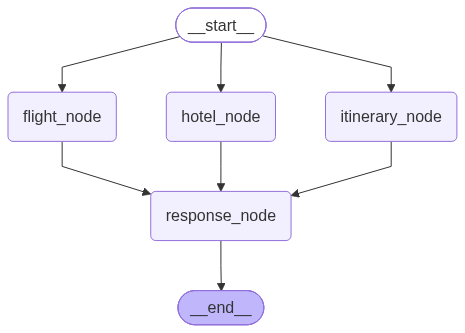

In [10]:
travel_workflow

In [11]:
from components.graph.state import initial_state

In [19]:
def run_trip_planner_agent(user_query: str):
    try:

        travel_config = {
        "configurable": {
            "thread_id": "travel-test-1"
        }
    }

        final_state = travel_workflow.invoke(
            initial_state(user_query), #no {} because they create a set and langgraph cannot use them gives error-2
            config = travel_config
        )

        final_result = final_state['messages'][-1].content

        return {
            "thread_id": travel_config['configurable']['thread_id'],
            "final_result": final_result,
            "flight_result": final_state.get("flight_result", ""),
            "hotel_result": final_state.get("hotel_result", ""),
            "itineary_result": final_state.get("itineary_result", ""),
            "travellers": final_state.get("travellers", "")
        }

    except Exception as e:
        print(f"Error occured while running whole workflow: {str(e)}")

In [20]:
user_input = "Plan a 3 day trip to Italy, include sightseeing, flights and itinerary"
response = run_trip_planner_agent(user_input)

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


Inside web search tool


In [24]:
print("Final Respopnse")
print("-"*80)
print(response["final_result"])

Final Respopnse
--------------------------------------------------------------------------------
Ciao! Here is your personalized 3-day travel plan for two to the magnificent city of Rome, Italy, focusing on ancient wonders, delightful cuisine, and practical budget-aware tips.

---

## 🇮🇹 Your Roman Holiday: A 3-Day Itinerary for Two 🇮🇹

### 1. Trip Summary

*   **Destination:** Rome, Italy
*   **Duration:** 3 Days
*   **Travelers:** 2
*   **Focus:** Immerse yourselves in ancient history, stunning art, delicious food, and the vibrant atmosphere of Rome. This itinerary is designed to be practical and budget-aware, ensuring you experience the best of the Eternal City without feeling rushed.

---

### 2. Flight Information

We've found several scheduled flights arriving at **Leonardo Da Vinci (Fiumicino) Airport (FCO)** on **August 30, 2026**. Please note that **live flight API data typically does not include ticket prices**, as these fluctuate constantly based on demand and booking time. 

In [23]:
response.keys()

dict_keys(['thread_id', 'final_result', 'flight_result', 'hotel_result', 'itineary_result', 'travellers'])